4_Bike_Sharing

¿Quién lo creó y cómo se obtuvieron los datos?
El dataset fue creado por el Dr. Hadi Fanaee-T del Laboratorio de Inteligencia Artificial y Soporte a la Decisión (LIAAD), en la Universidad de Porto, Portugal, en 2013, y se publicó en el UCI Machine Learning Repository. Los datos se obtuvieron directamente del sistema Capital Bikeshare de Washington D.C., que es uno de los sistemas de alquiler de bicicletas más grandes de los Estados Unidos. Los registros de alquileres fueron combinados con datos meteorológicos históricos (temperatura, humedad, viento, condiciones climáticas) y datos calendáricos (días festivos, días laborables) para enriquecer el dataset.

¿De qué trata?
Este dataset contiene el conteo horario y diario de bicicletas alquiladas entre los años 2011 y 2012 en el sistema Capital Bikeshare, junto con la información meteorológica y estacional correspondiente. Refleja el comportamiento de los usuarios de bicicletas compartidas en función de condiciones externas.

¿Qué contiene?
Ambos archivos (hour.csv y day.csv) contienen los siguientes campos: instant (índice), dteday (fecha), season (estación: 1=primavera, 2=verano, 3=otoño, 4=invierno), yr (año: 0=2011, 1=2012), mnth (mes del 1 al 12), hr (hora del 0 al 23, solo en hour.csv), holiday (si el día es festivo), weekday (día de la semana), workingday (1 si no es fin de semana ni festivo), weathersit (situación meteorológica en 4 niveles, desde cielo despejado hasta lluvia intensa con hielo), temp (temperatura normalizada), atemp (temperatura sensación normalizada), hum (humedad normalizada), windspeed (velocidad del viento normalizada), casual (usuarios ocasionales), registered (usuarios registrados) y cnt (total de bicicletas alquiladas). El dataset hourly contiene 17.379 instancias con 12 atributos enteros y de valor real, y un objetivo continuo.

Objetivo del modelo
Es un problema de regresión: predecir el número total de bicicletas alquiladas (cnt) en una hora o día determinado, en función de las condiciones climáticas, la hora del día, el día de la semana y la época del año. Puede abordarse también como clasificación si se discretiza la demanda en niveles (baja, media, alta). Variables clave son la temperatura, la hora y si es día laborable o festivo. Algoritmos recomendados: Random Forest Regressor, Gradient Boosting, y redes neuronales para capturar las relaciones estacionales y temporales.

In [1]:
# ============================================================
# LIBRERÍAS GENERALES
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split

In [2]:
# ── PASO 1: CARGA ───────────────────────────────────────────
df_bike = pd.read_csv('Datasets/4_Bike_Sharing/train.csv')

print('Shape:', df_bike.shape)
print('Columnas:', list(df_bike.columns))
print('Nulos:', df_bike.isnull().sum().sum())
print('\nPrimeras 3 filas:')
print(df_bike.head(3))

Shape: (10886, 12)
Columnas: ['datetime', 'season', 'holiday', 'workingday', 'weather', 'temp', 'atemp', 'humidity', 'windspeed', 'casual', 'registered', 'count']
Nulos: 0

Primeras 3 filas:
              datetime  season  holiday  workingday  weather  temp   atemp  \
0  2011-01-01 00:00:00       1        0           0        1  9.84  14.395   
1  2011-01-01 01:00:00       1        0           0        1  9.02  13.635   
2  2011-01-01 02:00:00       1        0           0        1  9.02  13.635   

   humidity  windspeed  casual  registered  count  
0        81        0.0       3          13     16  
1        80        0.0       8          32     40  
2        80        0.0       5          27     32  


In [3]:
# ── PASO 2: EXTRAER FEATURES DE LA FECHA ────────────────────
# El campo 'datetime' contiene año, mes, día y hora juntos.
# Lo separamos en columnas numéricas individuales.
df_bike['datetime']  = pd.to_datetime(df_bike['datetime'])
df_bike['hora']      = df_bike['datetime'].dt.hour       # 0 a 23
df_bike['mes']       = df_bike['datetime'].dt.month      # 1 a 12
df_bike['anio']      = df_bike['datetime'].dt.year       # 2011 o 2012
df_bike['dia_semana']= df_bike['datetime'].dt.dayofweek  # 0=lunes, 6=domingo

print('Features de fecha extraídas. Ejemplo:')
print(df_bike[['datetime','hora','mes','anio','dia_semana']].head(3))

Features de fecha extraídas. Ejemplo:
             datetime  hora  mes  anio  dia_semana
0 2011-01-01 00:00:00     0    1  2011           5
1 2011-01-01 01:00:00     1    1  2011           5
2 2011-01-01 02:00:00     2    1  2011           5


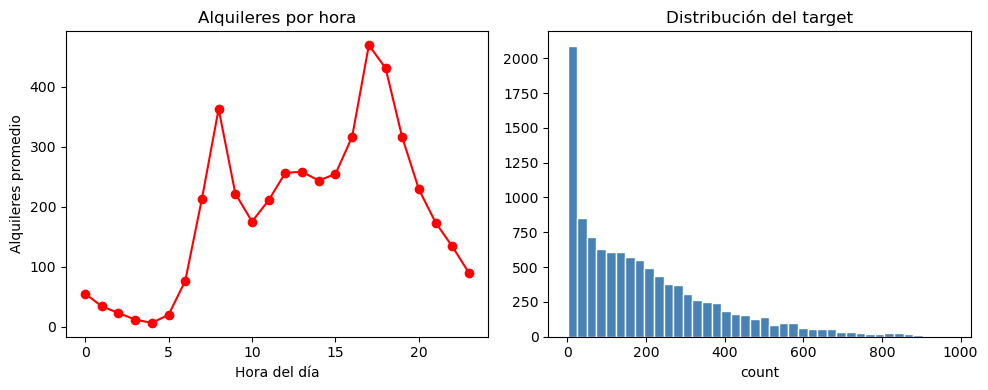

In [4]:
# ── PASO 3: GRAFICAR — como hace el docente ─────────────────
# Ver el patrón de alquileres por hora del día
alq_por_hora = [df_bike[df_bike['hora']==h]['count'].mean() for h in range(24)]

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(range(24), alq_por_hora, 'ro-', ms=6)
plt.xlabel('Hora del día')
plt.ylabel('Alquileres promedio')
plt.title('Alquileres por hora')

plt.subplot(1, 2, 2)
plt.hist(df_bike['count'], bins=40, color='steelblue', edgecolor='white')
plt.xlabel('count')
plt.title('Distribución del target')
plt.tight_layout()
plt.show()

In [5]:
# ── PASO 4: CONSTRUIR X e y ─────────────────────────────────
# NO incluir 'casual' ni 'registered' — son parte del target
cols_features_bike = ['season','holiday','workingday','weather',
                      'temp','atemp','humidity','windspeed',
                      'hora','mes','anio','dia_semana']

X_raw_bike = df_bike[cols_features_bike].values.astype(float)
y_bike     = df_bike['count'].values.astype(float)
m_bike     = y_bike.size

print('X shape:', X_raw_bike.shape)
print('y shape:', y_bike.shape)
print('Nulos:', np.isnan(X_raw_bike).sum())

X shape: (10886, 12)
y shape: (10886,)
Nulos: 0


In [6]:
def featureNormalize(X):
    """
    Normaliza las features de X.
    Para cada columna: resta la media y divide por la desviación estándar.
    
    Retorna:
      X_norm : X normalizado (mismo tamaño que X)
      mu     : media de cada columna (se guarda para normalizar datos nuevos)
      sigma  : desviación estándar de cada columna
    """
    X_norm = X.copy()
    mu     = np.mean(X, axis=0)   # media de cada columna
    sigma  = np.std(X, axis=0)    # desviación estándar de cada columna
    X_norm = (X - mu) / sigma     # estandarización Z-score
    return X_norm, mu, sigma

In [7]:
# ── PASO 5: NORMALIZAR y COLUMNA DE UNOS ────────────────────
X_norm_bike, mu_bike, sigma_bike = featureNormalize(X_raw_bike)
X_bike = np.concatenate([np.ones((m_bike, 1)), X_norm_bike], axis=1)

print('X_bike final:', X_bike.shape)
print(' X:', X_bike.shape, '| y:', y_bike.shape)

X_bike final: (10886, 13)
 X: (10886, 13) | y: (10886,)
